In [ ]:
import sys
!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install "numpy<2.1" pandas scikit-learn matplotlib seaborn

In [ ]:
!pip3 install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import sys
!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install matplotlib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv('/Users/kitkat/Projects/EDA/brazillian e commerce dataset by olisit/olist_orders_dataset.csv')
customers = pd.read_csv('/Users/kitkat/Projects/EDA/brazillian e commerce dataset by olisit/olist_customers_dataset.csv')
order_items = pd.read_csv('/Users/kitkat/Projects/EDA/brazillian e commerce dataset by olisit/olist_order_items_dataset.csv')
reviews = pd.read_csv('/Users/kitkat/Projects/EDA/brazillian e commerce dataset by olisit/olist_order_reviews_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print("Data loaded!")
print(orders.shape, customers.shape)

## Customer Churn Prediction
**Objective:** Predict which customers are likely to never return (churn) based on their purchase behaviour.

**Dataset:** Olist Brazilian E-Commerce (2016-2018)
**Target:** Churned (1) = no purchase in 180+ days, Active (0) = purchased within 180 days

In [ ]:
# Define churn: customer who never ordered again after their first order
# We'll use customer_unique_id to track real customers across orders

# Step 1: Merge orders with customers
df = orders.merge(customers, on='customer_id')

# Step 2: Keep only delivered orders
df = df[df['order_status'] == 'delivered']

# Step 3: Find each customer's order count and last order date
reference_date = df['order_purchase_timestamp'].max()

customer_stats = df.groupby('customer_unique_id').agg(
order_count=('order_id', 'count'),
last_order_date=('order_purchase_timestamp', 'max'),
first_order_date=('order_purchase_timestamp', 'min')
).reset_index()

# Step 4: Define churn
customer_stats['days_since_last_order'] = (reference_date - customer_stats['last_order_date']).dt.days
customer_stats['churned'] = (customer_stats['days_since_last_order'] > 180).astype(int)

print(customer_stats.shape)
print(customer_stats['churned'].value_counts())

## Defining Churn
A customer is marked as churned if they haven't placed an order in the last 180 days
(relative to the dataset's end date — August 2018).

**Finding:** 59% of customers churned — majority never returned after their first purchase.
This indicates a significant retention problem for the business.

In [ ]:
# Add review score per customer (average)
avg_review = reviews.groupby('order_id')['review_score'].mean().reset_index()
avg_review.columns = ['order_id', 'avg_review_score']

order_with_review = df.merge(avg_review, on='order_id', how='left')

customer_reviews = order_with_review.groupby('customer_unique_id')['avg_review_score'].mean().reset_index()
customer_reviews.columns = ['customer_unique_id', 'avg_review_score']

# Add average spend per customer
order_spend = order_items.groupby('order_id')['price'].sum().reset_index()
order_spend.columns = ['order_id', 'total_spend']

order_with_spend = df.merge(order_spend, on='order_id', how='left')
customer_spend = order_with_spend.groupby('customer_unique_id')['total_spend'].mean().reset_index()
customer_spend.columns = ['customer_unique_id', 'avg_spend']

# Combine everything
features = customer_stats.merge(customer_reviews, on='customer_unique_id', how='left')
features = features.merge(customer_spend, on='customer_unique_id', how='left')

print(features.shape)
print(features.head(10))

## Feature Engineering
Three features were created for each customer:
- **order_count** — total number of orders placed
- **avg_review_score** — average satisfaction rating
- **avg_spend** — average amount spent per order

Note: days_since_last_order was excluded to prevent data leakage
(it directly defines the churn label).

In [15]:
# Drop columns not needed for ML
X = features[['order_count',  'avg_review_score', 'avg_spend']]
y = features['churned']

# Fill any missing values
X = X.fillna(X.median())

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (74686, 3)
Test size: (18672, 3)


In [ ]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000,class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Evaluate
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))

## Model 1: Logistic Regression
A simple baseline model. Results showed poor performance (48% accuracy)
due to limited feature complexity and class imbalance.

In [ ]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))

## Model 2: Random Forest
100 decision trees voting together. Outperformed Logistic Regression with 61% accuracy.
Better at capturing non-linear patterns in customer behaviour.

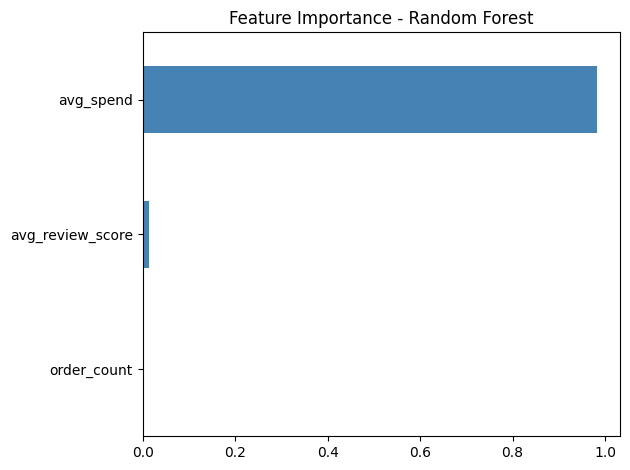

In [19]:
# Which features matter most?
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

## Key Insight: What drives churn?
Average spend is the strongest predictor of churn — far more important than
order count or review score.
**Business recommendation:** Focus retention campaigns on spend-based segmentation.
High-spend customers are most likely to return and worth targeting with loyalty rewards.